In [2]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random

In [3]:
ALLOW_PREFIXES = {"align", "reward"}

def strip_prefix(col: str) -> str:
    return col.split(".", 1)[1] if "." in col else col

def pretty_name(col: str) -> str:
    return strip_prefix(col).replace("_", " ").strip()


Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db seed=123 (/home/epigou/cs_9170_project/training_runs/EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db/seed_123)
Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db seed=42 (/home/epigou/cs_9170_project/training_runs/EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db/seed_42)
Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db seed=999 (/home/epigou/cs_9170_project/training_runs/EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db/seed_999)
Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_07551908 seed=123 (/home/epigou/cs_9170_project/training_runs/EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_07551908/seed_123)
Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_07551908 seed=42 (/home/epigou/cs_9170_project/training_runs/EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_07551908/seed_42)
Loaded seed run: exp=EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_

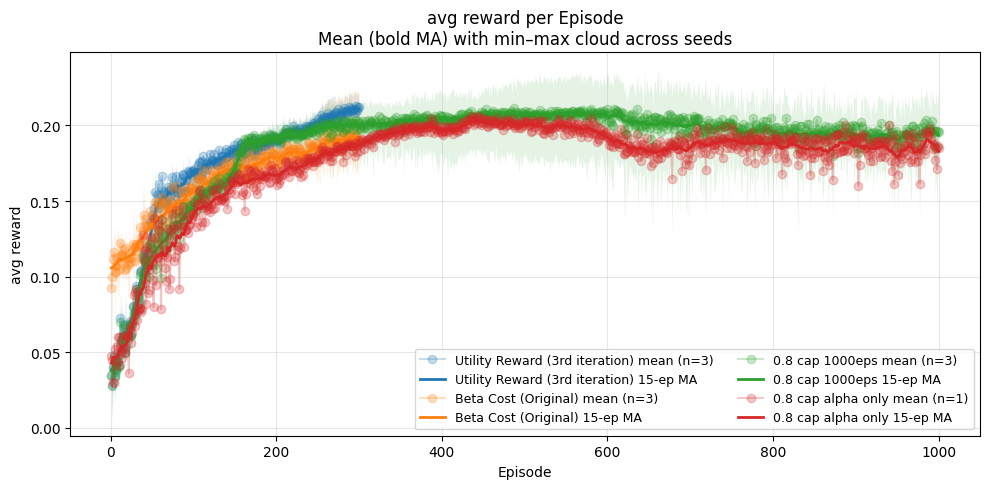

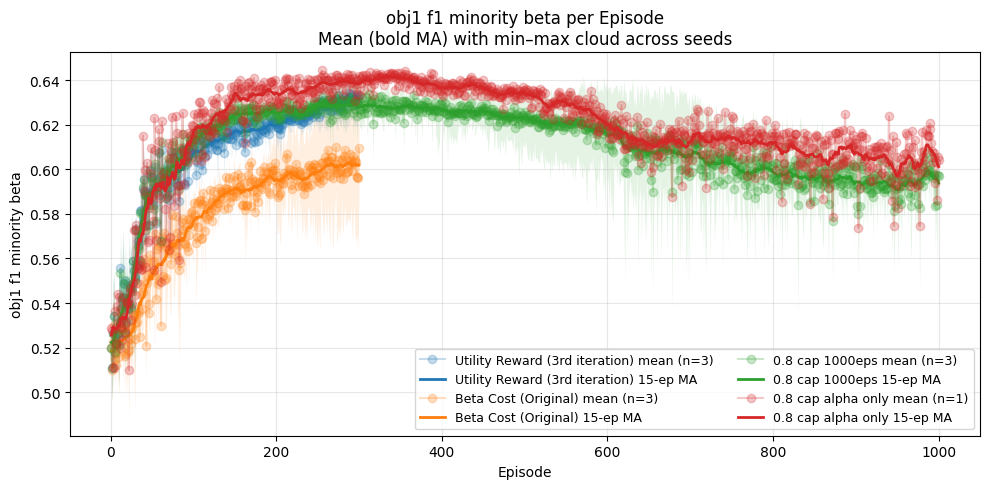

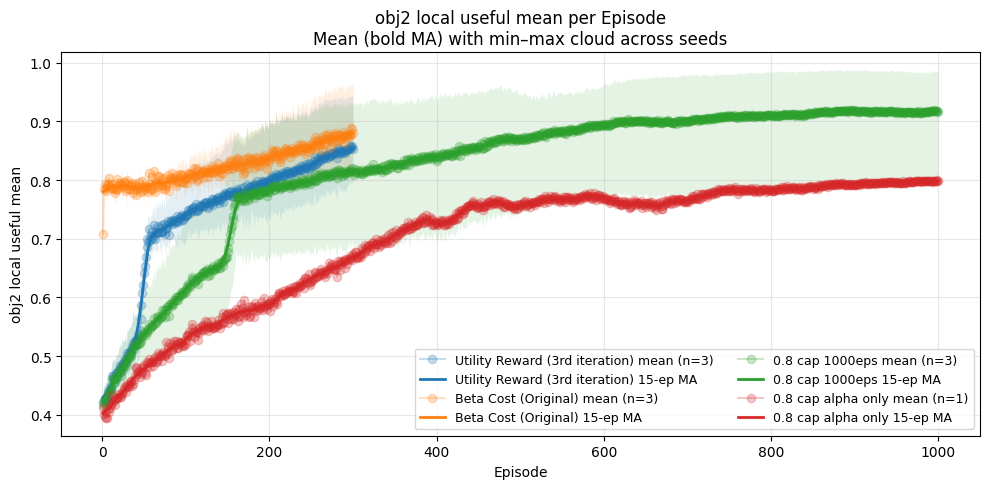

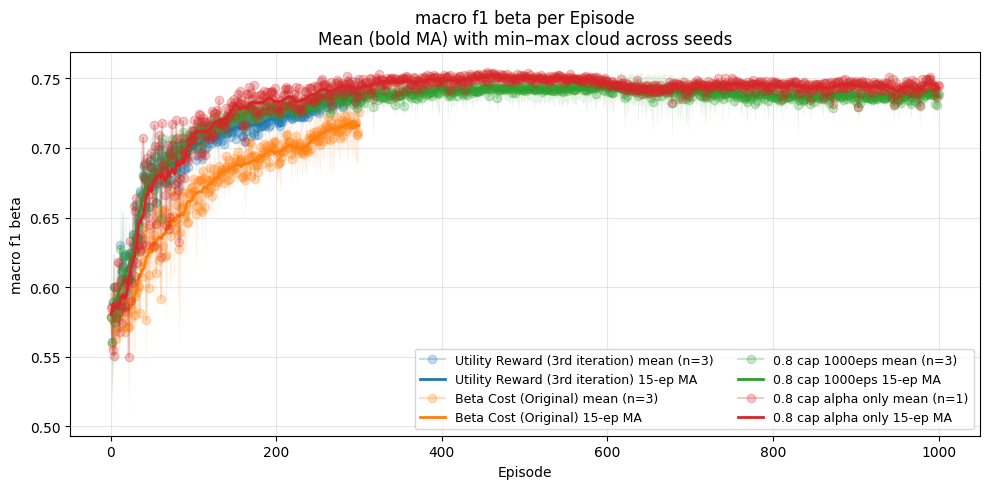

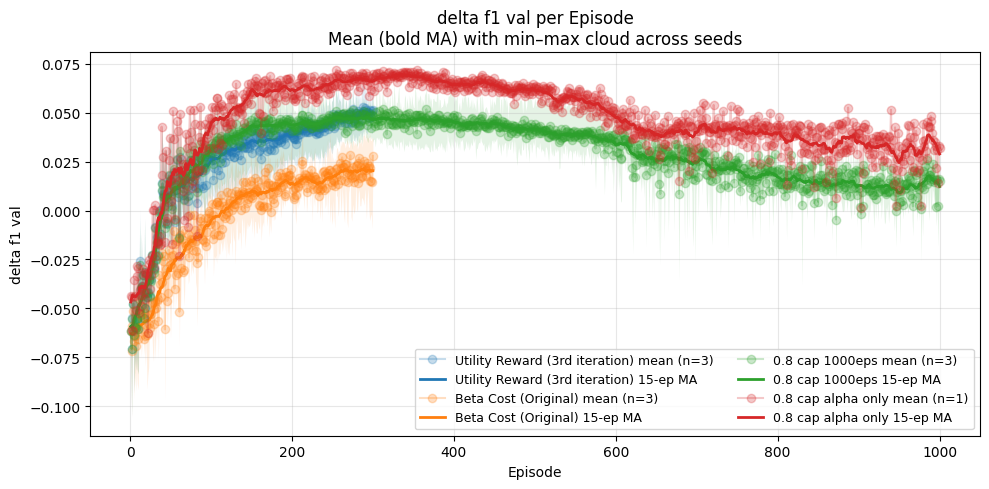

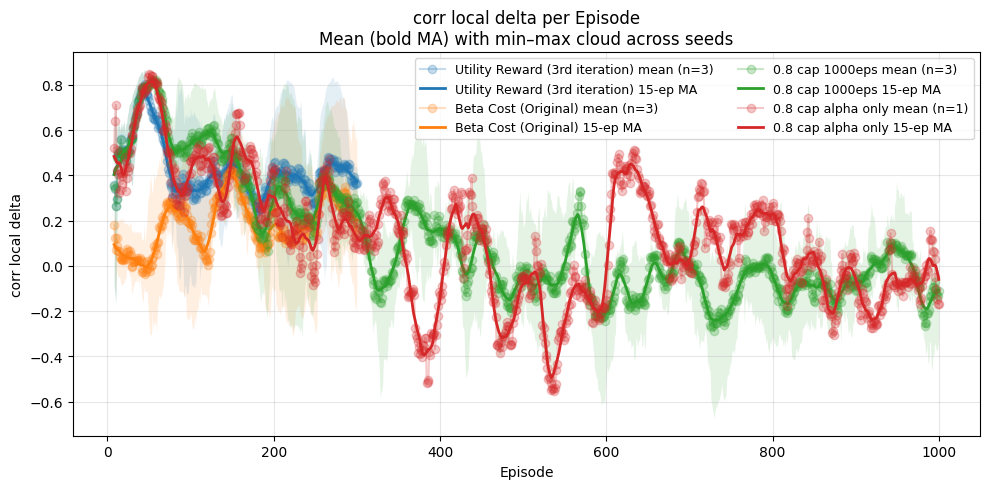

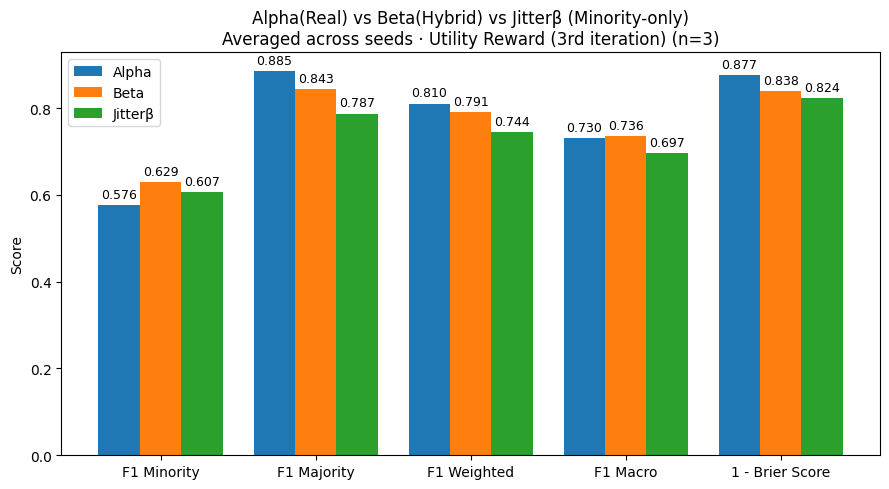


Beta vs Alpha · averaged across seeds · Utility Reward (3rd iteration):
  F1 Minority: +0.052 (+9.1%)
  F1 Majority: -0.042 (-4.7%)
  F1 Weighted: -0.019 (-2.4%)
  F1 Macro: +0.005 (+0.7%)
  1 - Brier Score: -0.038 (-4.4%)


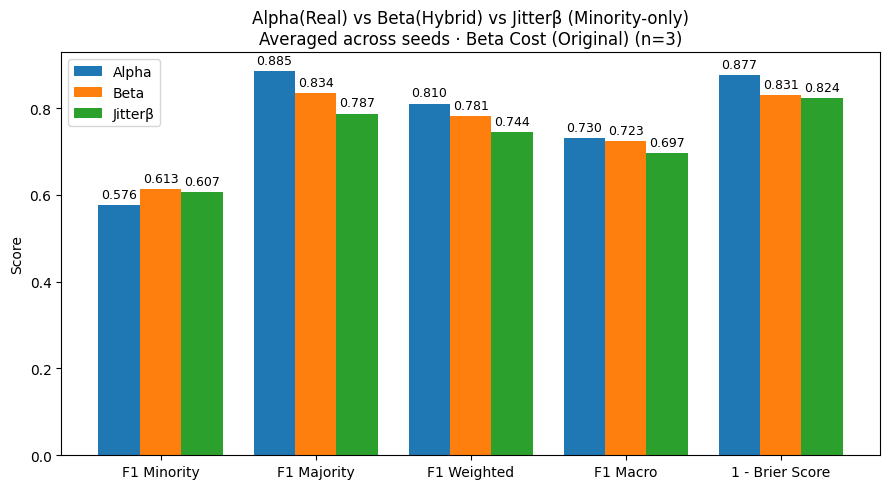


Beta vs Alpha · averaged across seeds · Beta Cost (Original):
  F1 Minority: +0.037 (+6.4%)
  F1 Majority: -0.051 (-5.7%)
  F1 Weighted: -0.030 (-3.7%)
  F1 Macro: -0.007 (-1.0%)
  1 - Brier Score: -0.046 (-5.2%)


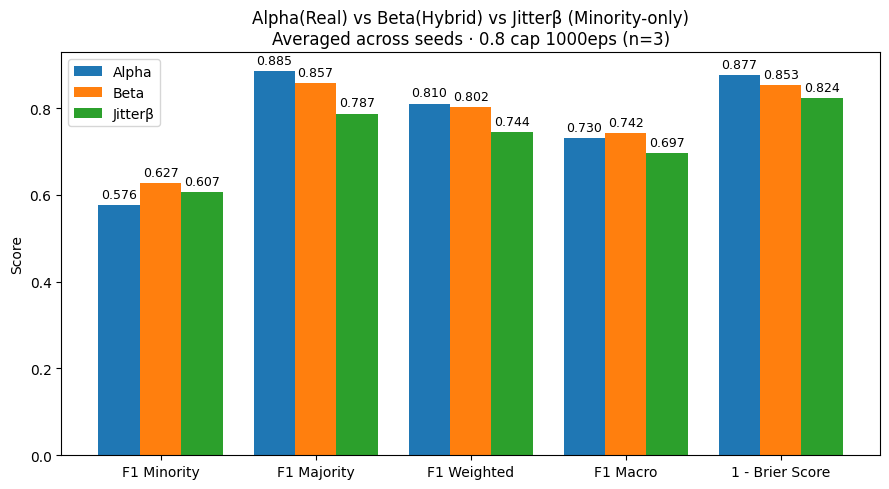


Beta vs Alpha · averaged across seeds · 0.8 cap 1000eps:
  F1 Minority: +0.051 (+8.8%)
  F1 Majority: -0.027 (-3.1%)
  F1 Weighted: -0.008 (-1.0%)
  F1 Macro: +0.012 (+1.6%)
  1 - Brier Score: -0.023 (-2.6%)


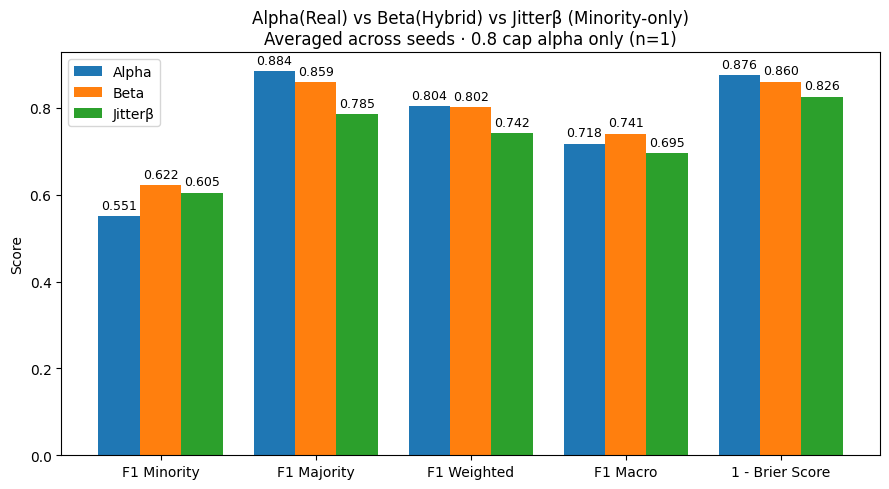


Beta vs Alpha · averaged across seeds · 0.8 cap alpha only:
  F1 Minority: +0.071 (+12.9%)
  F1 Majority: -0.025 (-2.8%)
  F1 Weighted: -0.002 (-0.2%)
  F1 Macro: +0.023 (+3.2%)
  1 - Brier Score: -0.016 (-1.8%)


In [21]:
# plot_experiment_minmax.py
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from typing import List, Dict

# ============================
# Config
# ============================
WINDOW = 15  # moving average window (episodes)

# Only plot these metric groups
ALLOW_PREFIXES = {"align", "reward"}

# Exclude from plotting
EXCLUDE_COLS = {"episode", "wall_seconds"}

# Optional: have these columns (by stripped name) appear first if present
PREFERRED_ORDER = [
    # reward_metrics
    "avg_reward",
    "obj1_f1_minority_beta",
    "obj2_local_useful_mean",
    "macro_f1_beta",
    # align_metrics
    "delta_f1_val",
    "corr_local_delta",
]

# ---- Set your experiment parent folders and labels here ----
# Use the EXPERIMENT_LABELS dict to define both the experiment roots and their display names.
# The keys are the experiment folder names (not full paths), and the values are the legend labels.

EXPERIMENT_LABELS = {
    "EP300_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8d8d25db": "Utility Reward (3rd iteration)",
    "EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_07551908": "Beta Cost (Original)",
    # "EP300_TRJ2000_REAL3000_BIAS0.35_NR0_TAU0.1_10f1574f": "EMA Reward (2nd iteration)",
    # "EP1000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_c00d8197": "Utility Reward (1000 eps)",
    # "EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce": "Utility Reward (5000 eps)",
    # "EP300_TRJ2000_REAL3000_BIAS0.1_NR1_TAU0.1_64322409": "Bias 0.1",
    "EP1000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_c00d8197": "0.8 cap 1000eps",
    "EP1000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_8be955ca": "0.8 cap alpha only",
    # "EP850_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_4027ae66": "850eps 0.75 cap",
    # "EP500_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_959f550c": "0.8 obj_2 cap"
}

# Build EXPERIMENT_ROOTS from the keys of EXPERIMENT_LABELS
EXPERIMENT_ROOTS = [
    os.path.join("training_runs", exp_name)
    for exp_name in EXPERIMENT_LABELS.keys()
]

# If not set in EXPERIMENT_LABELS, script will look for <experiment_root>/label.txt
# (first line is used). Otherwise it falls back to the folder name.


# ============================
# Helpers
# ============================
def strip_prefix(col: str) -> str:
    return col.split(".", 1)[1] if "." in col else col

def pretty_name(col: str) -> str:
    return strip_prefix(col).replace("_", " ").strip()

def is_seed_dir(path: str) -> bool:
    return (
        os.path.isdir(path)
        and os.path.isfile(os.path.join(path, "metrics.csv"))
        and os.path.isfile(os.path.join(path, "meta.json"))
    )

def expand_to_seed_dirs(paths: List[str]) -> Dict[str, List[str]]:
    """
    Returns mapping: experiment_root -> [seed_dir, ...]
    Accepts: experiment roots (with seed_*), seed dirs, or legacy flat run dirs.
    """
    out: Dict[str, List[str]] = {}
    for p in paths:
        p = os.path.abspath(p.rstrip("/"))
        if not os.path.exists(p):
            print(f"[warn] Path does not exist: {p}")
            continue

        # If given a seed dir directly, its experiment root is the parent
        if is_seed_dir(p) and os.path.basename(p).startswith("seed_"):
            exp_root = os.path.dirname(p)
            out.setdefault(exp_root, []).append(p)
            continue

        # If it's an experiment root (contains seed_* dirs)
        if os.path.isdir(p):
            seed_dirs = [
                os.path.join(p, d) for d in os.listdir(p)
                if d.startswith("seed_") and is_seed_dir(os.path.join(p, d))
            ]
            if seed_dirs:
                out.setdefault(p, []).extend(sorted(seed_dirs))
                continue

        # Legacy flat run dir (metrics at root)
        if is_seed_dir(p):
            # treat the dir itself as a "seed folder"; parent becomes the exp root
            exp_root = os.path.dirname(p)
            out.setdefault(exp_root, []).append(p)
            continue

        print(f"[warn] Skipping path (not a seed/experiment/run): {p}")
    return out

def read_meta(seed_dir: str) -> Dict:
    with open(os.path.join(seed_dir, "meta.json"), "r") as f:
        meta = json.load(f)
    # Optionally merge experiment-level config (won't override seed-level)
    parent_meta = os.path.join(os.path.dirname(seed_dir), "meta.json")
    if os.path.isfile(parent_meta):
        try:
            with open(parent_meta, "r") as f:
                exp_meta = json.load(f)
            meta = {**exp_meta.get("config", {}), **meta}
        except Exception:
            pass
    return meta

def read_metrics(seed_dir: str) -> pd.DataFrame:
    df = pd.read_csv(os.path.join(seed_dir, "metrics.csv"))
    for c in df.columns:
        if c not in EXCLUDE_COLS:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "episode" not in df.columns:
        df.insert(0, "episode", np.arange(1, len(df) + 1))
    return df

def choose_label_for_experiment(exp_root: str, any_seed_meta: Dict) -> str:
    # 1) Explicit mapping by abs path
    if exp_root in EXPERIMENT_LABELS:
        return EXPERIMENT_LABELS[exp_root]

    # 2) Explicit mapping by basename
    base = os.path.basename(exp_root)
    if base in EXPERIMENT_LABELS:
        return EXPERIMENT_LABELS[base]

    # 3) label.txt (first line)
    label_file = os.path.join(exp_root, "label.txt")
    if os.path.isfile(label_file):
        try:
            with open(label_file, "r", encoding="utf-8") as f:
                line = f.readline().strip()
            if line:
                return line
        except Exception:
            pass

    # 4) Optional fields in parent meta.json (display_name / label)
    parent_meta = os.path.join(exp_root, "meta.json")
    if os.path.isfile(parent_meta):
        try:
            with open(parent_meta, "r", encoding="utf-8") as f:
                exp_meta = json.load(f)
            for k in ("display_name", "label", "name", "title"):
                if k in exp_meta and isinstance(exp_meta[k], str) and exp_meta[k].strip():
                    return exp_meta[k].strip()
        except Exception:
            pass

    # 5) Fallback to folder name
    return base

# ============================
# Load (group by experiment root)
# ============================
def _read_final_row(seed_dir: str):
    p = os.path.join(seed_dir, "final_test_metrics.csv")
    if os.path.isfile(p):
        df = pd.read_csv(p)
        if not df.empty:
            return df.iloc[-1]
    return None

def load_by_experiment(exp_to_seed_dirs: Dict[str, List[str]]):
    """
    Returns groups keyed by experiment_root (abs path):
      {
        'dfs': [per-seed dataframes],
        'seeds': [seed ids or None],
        'paths': [seed dirs],
        'label': custom/fallback label string,
        'final_rows': [per-seed final_test_metrics rows]
      }
    """
    from collections import defaultdict
    groups = defaultdict(lambda: {"dfs": [], "seeds": [], "paths": [], "label": None, "final_rows": []})
    for exp_root, seed_dirs in exp_to_seed_dirs.items():
        seed_dirs = sorted(seed_dirs)
        any_meta = None
        for sd in seed_dirs:
            try:
                meta = read_meta(sd)
                df = read_metrics(sd)
                groups[exp_root]["dfs"].append(df)
                groups[exp_root]["paths"].append(sd)
                groups[exp_root]["seeds"].append(meta.get("seed", None))
                any_meta = any_meta or meta

                fr = _read_final_row(sd)
                if fr is not None:
                    groups[exp_root]["final_rows"].append(fr)
                print(f"Loaded seed run: exp={os.path.basename(exp_root)} seed={meta.get('seed')} ({sd})")
            except Exception as e:
                print(f"[error] Failed to load {sd}: {e}")

        # Fallback: if no seed-level finals, try experiment rollup file
        if not groups[exp_root]["final_rows"]:
            rollup = os.path.join(exp_root, "final_test_metrics.csv")
            if os.path.isfile(rollup):
                try:
                    df_roll = pd.read_csv(rollup)
                    for _, r in df_roll.iterrows():
                        groups[exp_root]["final_rows"].append(r)
                    print(f"[info] Used experiment-level rollup finals from: {rollup}")
                except Exception as e:
                    print(f"[warn] Failed reading rollup finals at {rollup}: {e}")

        groups[exp_root]["label"] = choose_label_for_experiment(exp_root, any_meta or {})
    if not groups:
        raise SystemExit("No runs loaded. Check your experiment folder(s).")
    return groups


# ============================
# Column selection & order
# ============================
def build_plot_columns(groups) -> List[str]:
    all_cols = set()
    for g in groups.values():
        for df in g["dfs"]:
            all_cols.update(df.columns)
    metric_cols = [
        c for c in all_cols
        if c not in EXCLUDE_COLS and (c.split(".", 1)[0] in ALLOW_PREFIXES)
    ]
    preferred_present, seen = [], set()
    for want in PREFERRED_ORDER:
        for c in metric_cols:
            if strip_prefix(c) == want and c not in seen:
                preferred_present.append(c)
                seen.add(c)
    remaining = sorted([c for c in metric_cols if c not in seen], key=lambda x: strip_prefix(x))
    return preferred_present + remaining

# ============================
# Plotting
# ============================
def plot_groups(groups, plot_columns: List[str], window: int = WINDOW):
    palette = cycle([
        "tab:blue", "tab:orange", "tab:green", "tab:red",
        "tab:purple", "tab:brown", "tab:pink", "tab:gray",
        "tab:olive", "tab:cyan"
    ])

    color_map = {exp_root: next(palette) for exp_root in groups.keys()}
    label_map = {exp_root: groups[exp_root]["label"] for exp_root in groups.keys()}

    for col in plot_columns:
        plt.figure(figsize=(10, 5))
        plotted_any = False

        for exp_root, bucket in groups.items():
            series_list, seed_ids = [], []
            for df, seed in zip(bucket["dfs"], bucket["seeds"]):
                if col not in df.columns:
                    continue
                s = df[["episode", col]].dropna()
                s[col] = pd.to_numeric(s[col], errors="coerce")
                s = s.dropna().set_index("episode").sort_index()[col]
                series_list.append(s)
                seed_ids.append(seed)

            if not series_list:
                continue

            aligned = pd.concat(series_list, axis=1)
            aligned.columns = [str(s) for s in seed_ids]

            mean_y = aligned.mean(axis=1, skipna=True)
            min_y  = aligned.min(axis=1, skipna=True)
            max_y  = aligned.max(axis=1, skipna=True)
            x = mean_y.index.values

            mean_ma = pd.Series(mean_y).rolling(window=window, min_periods=1, center=True).mean().values

            color = color_map[exp_root]
            base_label = label_map[exp_root]
            n_seeds = aligned.shape[1]

            # min–max cloud across seeds
            plt.fill_between(x, min_y.values, max_y.values, alpha=0.12, color=color, linewidth=0)

            # across-seed mean (faint)
            plt.plot(x, mean_y.values, linestyle='-', marker='o', alpha=0.25, color=color,
                     label=f"{base_label} mean (n={n_seeds})")

            # moving average of across-seed mean (bold)
            plt.plot(x, mean_ma, color=color, linewidth=2,
                     label=f"{base_label} {window}-ep MA")

            # (intentionally no dashed min/max seed overlays)
            plotted_any = True

        if not plotted_any:
            plt.close()
            print(f"Skipped '{col}' (not present).")
            continue

        plt.xlabel("Episode")
        plt.ylabel(pretty_name(col))
        plt.title(f"{pretty_name(col)} per Episode\nMean (bold MA) with min–max cloud across seeds")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()
# ---- Final test metrics config ----
TEST_METRICS = [
    ("f1_minority", "F1 Minority"),
    ("f1_majority", "F1 Majority"),
    ("f1_weighted", "F1 Weighted"),
    ("f1_macro",    "F1 Macro"),
    ("brier",       "1 - Brier Score"),  # we plot 1 - brier (higher is better)
]

def _mean_series(df: pd.DataFrame, col: str):
    return float(pd.to_numeric(df.get(col), errors="coerce").mean(skipna=True)) if col in df.columns else np.nan

def _means_for_prefix(df: pd.DataFrame, prefix: str) -> np.ndarray:
    vals = []
    for key, _ in TEST_METRICS:
        if key == "brier":
            v = _mean_series(df, f"{prefix}_brier")
            vals.append(1.0 - v if not np.isnan(v) else np.nan)
        else:
            vals.append(_mean_series(df, f"{prefix}_{key}"))
    return np.array(vals, dtype=float)

def plot_final_bars(groups):
    for exp_root, bucket in groups.items():
        rows = bucket.get("final_rows", [])
        if not rows:
            print(f"\nNo final_test_metrics for {bucket['label']} — skipping.")
            continue

        # Normalize to DataFrame
        df = pd.DataFrame(rows)

        alpha_mean = _means_for_prefix(df, "alpha")
        beta_mean  = _means_for_prefix(df, "beta")

        # Jitter present only if any jitter_* cols exist
        has_jitter = any(col.startswith("jitter_") for col in df.columns)
        jitter_mean = _means_for_prefix(df, "jitter") if has_jitter else None

        groups_bars = [("Alpha", alpha_mean), ("Beta", beta_mean)]
        if jitter_mean is not None and not np.all(np.isnan(jitter_mean)):
            groups_bars.append(("Jitterβ", jitter_mean))

        x = np.arange(len(TEST_METRICS))
        n_groups = len(groups_bars)
        width = 0.8 / n_groups
        offsets = (np.arange(n_groups) - (n_groups - 1) / 2.0) * width

        plt.figure(figsize=(9, 5))
        bars_and_vals = []
        for gi, (gname, gvals) in enumerate(groups_bars):
            bars = plt.bar(x + offsets[gi], gvals, width, label=gname)
            bars_and_vals.append((bars, gvals))

        plt.xticks(x, [m[1] for m in TEST_METRICS])
        plt.ylabel("Score")
        n = len(df)
        title_core = "Alpha(Real) vs Beta(Hybrid)"
        if n_groups == 3:
            title_core += " vs Jitterβ (Minority-only)"
        plt.title(f"{title_core}\nAveraged across seeds · {bucket['label']} (n={n})")
        plt.legend()

        # Annotate bar values
        def autolabel(bars, values):
            for bar, val in zip(bars, values):
                if np.isnan(val):
                    continue
                h = bar.get_height()
                plt.annotate(f"{val:.3f}",
                             (bar.get_x() + bar.get_width()/2, h),
                             xytext=(0, 3), textcoords="offset points",
                             ha='center', va='bottom', fontsize=9)
        for bars, vals in bars_and_vals:
            autolabel(bars, vals)

        plt.tight_layout()
        plt.show()

        # Console diffs Beta vs Alpha
        print(f"\nBeta vs Alpha · averaged across seeds · {bucket['label']}:")
        for i, (a, b) in enumerate(zip(alpha_mean, beta_mean)):
            metric_name = TEST_METRICS[i][1]
            if np.isnan(a) or np.isnan(b):
                print(f"  {metric_name}: N/A (missing)")
            elif a == 0:
                print(f"  {metric_name}: N/A (alpha is zero)")
            else:
                diff = b - a
                pct  = 100.0 * diff / abs(a)
                print(f"  {metric_name}: {diff:+.3f} ({pct:+.1f}%)")


# ============================
# Main
# ============================
def main():
    if not EXPERIMENT_ROOTS:
        raise SystemExit("Set EXPERIMENT_ROOTS to your experiment parent folder(s).")

    exp_to_seed_dirs = expand_to_seed_dirs(EXPERIMENT_ROOTS)
    if not any(exp_to_seed_dirs.values()):
        raise SystemExit("No seed_* folders found under the provided experiment root(s).")

    groups = load_by_experiment(exp_to_seed_dirs)
    plot_cols = build_plot_columns(groups)

    print("\nWill plot these metrics:")
    for c in plot_cols:
        print("  -", strip_prefix(c))

    plot_groups(groups, plot_cols, window=WINDOW)
    plot_final_bars(groups)

if __name__ == "__main__":
    main()


[load] /home/epigou/cs_9170_project/training_runs/EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce/seed_123
[load] /home/epigou/cs_9170_project/training_runs/EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce/seed_42
[load] /home/epigou/cs_9170_project/training_runs/EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce/seed_999

[cols] available: __seed__, align.corr_local_delta, align.delta_f1_val, ema.ema_margin, ema.lambda_t, ema.margin_stale_minus_alpha, ema.w_target, ema.w_used, episode, newr.alpha_wrong_rate, newr.corr_factor_mean, newr.f1_minority_alpha, newr.f1_minority_beta_stale, newr.judge_conf_mean, newr.uncert_alpha_mean, reward.avg_reward, reward.macro_f1_beta, reward.obj1_f1_minority_beta, reward.obj2_local_useful_mean, wall_seconds


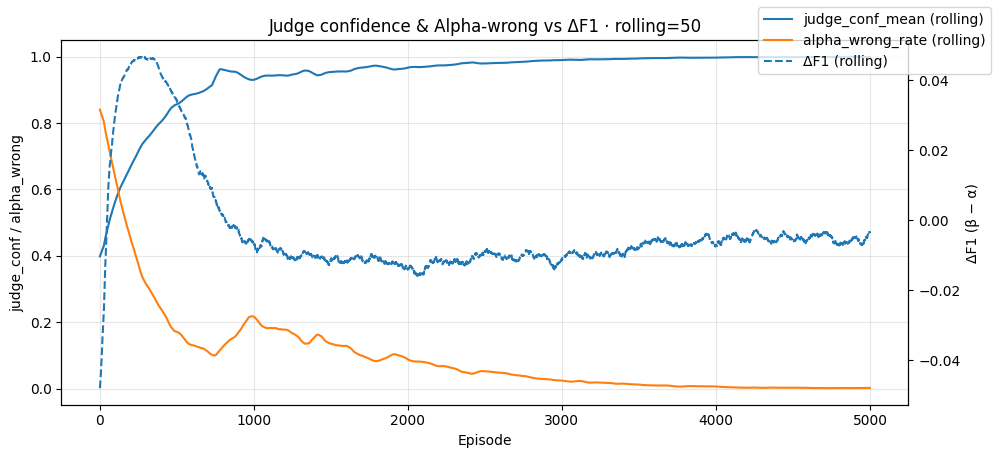

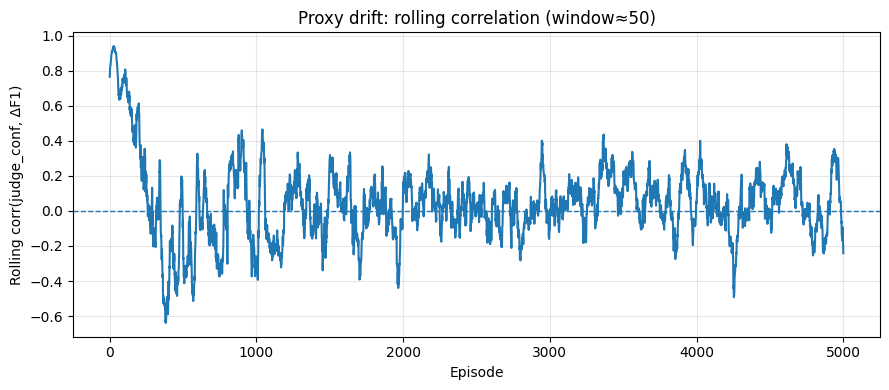

/tmp/ipykernel_23593/1019010116.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = y.groupby(pd.cut(x, bins=edges, include_lowest=True, duplicates="drop"))
/tmp/ipykernel_23593/1019010116.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = y.groupby(pd.cut(x, bins=edges, include_lowest=True, duplicates="drop"))


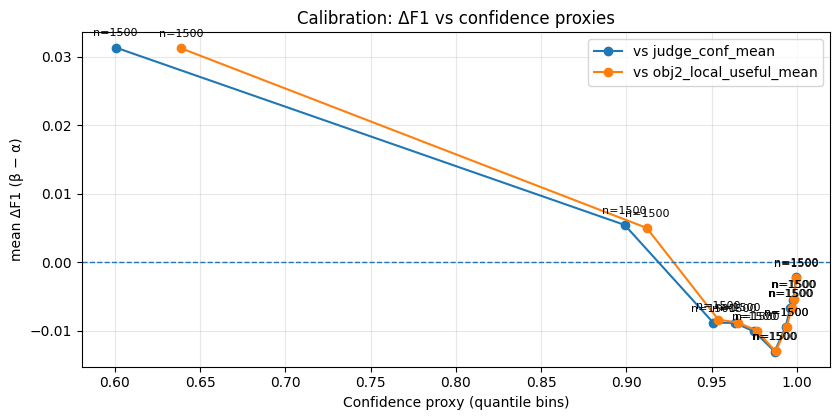

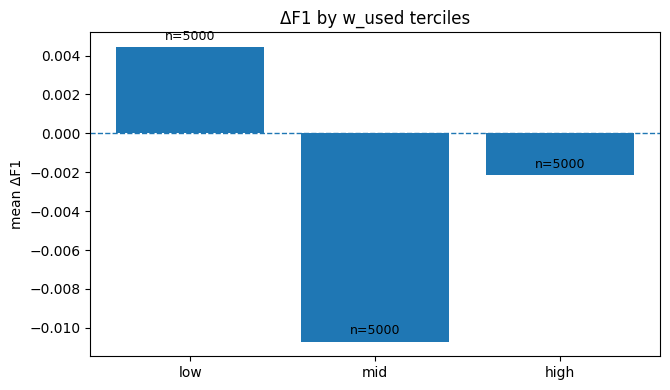

/tmp/ipykernel_23593/1019010116.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = y.groupby(pd.cut(x, bins=edges, include_lowest=True, duplicates="drop"))
/tmp/ipykernel_23593/1019010116.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = y.groupby(pd.cut(x, bins=edges, include_lowest=True, duplicates="drop"))
/tmp/ipykernel_23593/1019010116.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = y.groupb

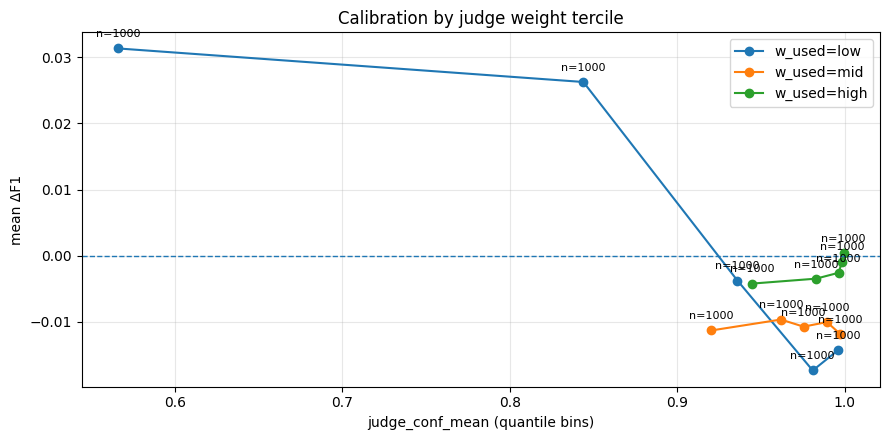

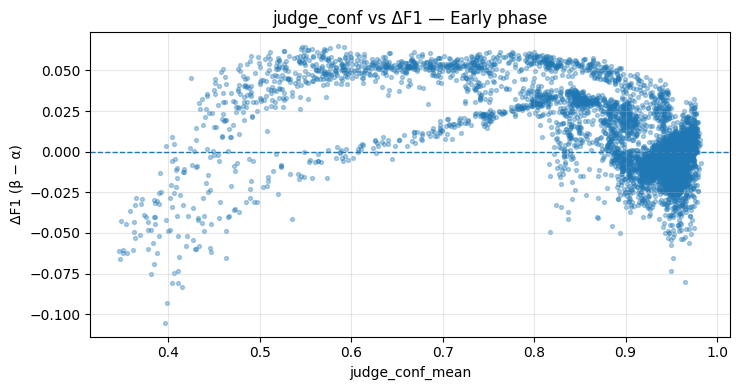

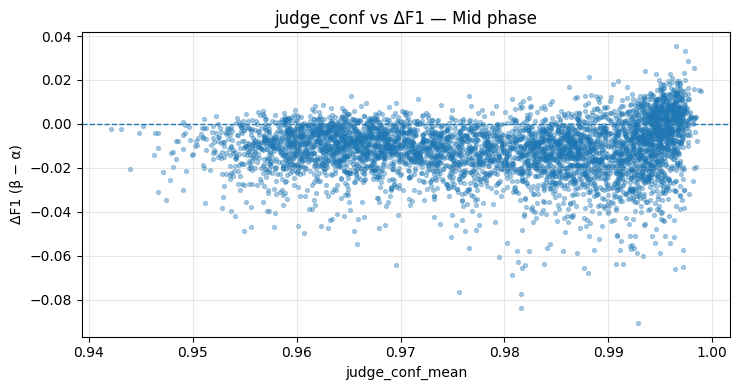

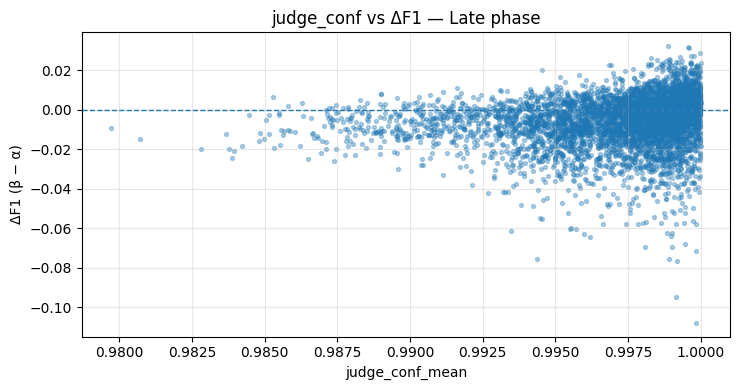

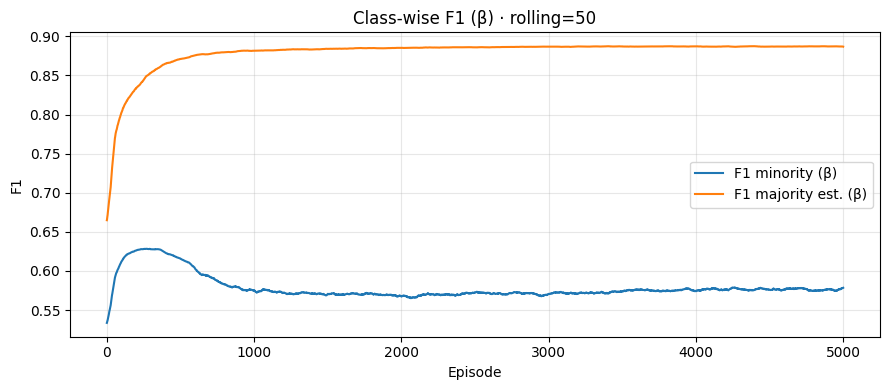

[info] Gate overlay skipped: missing ['episode', 'align.delta_f1_val', 'newr.local_cap_frac']


In [17]:
# === Standalone diagnostics focused on judge_conf alignment ===
# Set to the experiment you want to inspect:
EXP_ROOT = "training_runs/EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce"

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

ROLLING = 50        # smoothing window (episodes)
CAL_BINS = 10       # quantile bins for calibration
PHASE_SPLIT = (0.33, 0.66)  # early/mid/late quantiles

def find_seed_dirs(exp_root: str):
    exp_root = os.path.abspath(exp_root.rstrip("/"))
    if not os.path.exists(exp_root):
        raise FileNotFoundError(f"Experiment root not found: {exp_root}")
    seeds = []
    for name in sorted(os.listdir(exp_root)):
        child = os.path.join(exp_root, name)
        if name.startswith("seed_") and os.path.isdir(child) and os.path.isfile(os.path.join(child, "metrics.csv")):
            seeds.append(child)
    if not seeds and os.path.isfile(os.path.join(exp_root, "metrics.csv")):
        seeds = [exp_root]
    if not seeds:
        raise SystemExit(f"No seed_* folders (with metrics.csv) found under: {exp_root}")
    return seeds

def read_metrics(seed_dir: str) -> pd.DataFrame:
    p = os.path.join(seed_dir, "metrics.csv")
    df = pd.read_csv(p)
    for c in df.columns:
        if c != "episode":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "episode" not in df.columns:
        df.insert(0, "episode", np.arange(1, len(df) + 1))
    df["__seed__"] = os.path.basename(seed_dir)
    return df

def concat_seeds(seed_dirs):
    frames = []
    for sd in seed_dirs:
        try:
            frames.append(read_metrics(sd))
            print(f"[load] {sd}")
        except Exception as e:
            print(f"[error] failed reading {sd}: {e}")
    if not frames:
        raise SystemExit("No metrics loaded.")
    big = pd.concat(frames, axis=0, ignore_index=True)
    big = big.dropna(subset=["episode"]).sort_values(["episode", "__seed__"])
    return big

def have_cols(df, cols): return all(c in df.columns for c in cols)
def per_episode_mean(df, cols): return df.groupby("episode")[cols].mean(numeric_only=True)

# --- Load ---
seed_dirs = find_seed_dirs(EXP_ROOT)
df = concat_seeds(seed_dirs)
print("\n[cols] available:", ", ".join(sorted(df.columns)))

# Aliases for readability
COL_OBJ2 = "reward.obj2_local_useful_mean"          # mean local reward (may include boundary bonus if enabled)
COL_DF1  = "align.delta_f1_val"                     # ΔF1 = F1β − F1α on θ_val
COL_JC   = "newr.judge_conf_mean"                   # 1 - Brier on synthetic judged by blend
COL_AWR  = "newr.alpha_wrong_rate"                  # fraction alpha predicts majority on y=1 synthetic
COL_W    = "ema.w_used"                             # judge weight used this episode
COL_MAC  = "reward.macro_f1_beta"                   # macro-F1 of β on θ_val
COL_MINB = "reward.obj1_f1_minority_beta"           # minority F1 of β on θ_val
COL_CAPF = "newr.local_cap_frac"                    # fraction of samples capped by LOCAL_CAP (if logged)

# --- 0) Basic time series: judge_conf_mean, alpha_wrong_rate, ΔF1 ---
need0 = [c for c in [COL_JC, COL_AWR, COL_DF1] if c in df.columns]
if need0:
    ts = per_episode_mean(df, need0)
    ts_roll = ts.rolling(ROLLING, min_periods=1, center=True).mean()

    fig = plt.figure(figsize=(10, 4.6))
    ax1 = fig.add_subplot(111)
    if COL_JC in ts_roll:  ax1.plot(ts_roll.index, ts_roll[COL_JC], label="judge_conf_mean (rolling)")
    if COL_AWR in ts_roll: ax1.plot(ts_roll.index, ts_roll[COL_AWR], label="alpha_wrong_rate (rolling)")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("judge_conf / alpha_wrong"); ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    if COL_DF1 in ts_roll:  ax2.plot(ts_roll.index, ts_roll[COL_DF1], linestyle="--", label="ΔF1 (rolling)")
    ax2.set_ylabel("ΔF1 (β − α)")
    lines, labels = [], []
    for a in (ax1, ax2):
        h, l = a.get_legend_handles_labels()
        lines += h; labels += l
    fig.legend(lines, labels, loc="upper right")
    ax1.set_title(f"Judge confidence & Alpha-wrong vs ΔF1 · rolling={ROLLING}")
    plt.tight_layout(); plt.show()
else:
    print("[info] Skip time-series overlay: missing", [COL_JC, COL_AWR, COL_DF1])

# --- 1) Rolling correlation: judge_conf_mean vs ΔF1 ---
if have_cols(df, [COL_JC, COL_DF1]):
    ep = per_episode_mean(df, [COL_JC, COL_DF1]).dropna()
    # compute rolling Pearson corr on the episode-mean series
    s1, s2 = ep[COL_JC], ep[COL_DF1]
    def rolling_corr(a, b, w):
        out = []
        idx = a.index
        for i in range(len(idx)):
            lo = max(0, i - (w//2)); hi = min(len(idx), i + (w//2) + 1)
            aa, bb = a.iloc[lo:hi], b.iloc[lo:hi]
            if len(aa.dropna()) >= 5 and len(bb.dropna()) >= 5 and aa.std() > 1e-9 and bb.std() > 1e-9:
                out.append(aa.corr(bb))
            else:
                out.append(np.nan)
        return pd.Series(out, index=idx)
    r = rolling_corr(s1, s2, ROLLING)

    plt.figure(figsize=(9,4))
    plt.plot(r.index, r.values)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Episode"); plt.ylabel("Rolling corr(judge_conf, ΔF1)")
    plt.title(f"Proxy drift: rolling correlation (window≈{ROLLING})")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("[info] Skip rolling corr: missing", [COL_JC, COL_DF1])

# --- 2) Calibration: ΔF1 vs binned judge_conf_mean (and vs obj2 if present) ---
def calibration_curve(x, y, bins=CAL_BINS, label=""):
    x = x.clip(0, 1); y = y
    qs = np.linspace(0, 1, bins + 1)
    edges = x.quantile(qs).values
    edges = np.unique(edges)
    if len(edges) < 3:
        print("[info] Calibration: too few distinct values to bin.")
        return
    g = y.groupby(pd.cut(x, bins=edges, include_lowest=True, duplicates="drop"))
    centers = np.array([iv.mid for iv in g.mean().index])
    means   = g.mean().values
    counts  = g.size().values
    plt.plot(centers, means, marker="o", label=label)
    for cx, cy, n in zip(centers, means, counts):
        plt.annotate(f"n={int(n)}", (cx, cy), textcoords="offset points", xytext=(0,8),
                     ha="center", fontsize=8)

if have_cols(df, [COL_JC, COL_DF1]):
    plt.figure(figsize=(8.5,4.3))
    calibration_curve(df[COL_JC], df[COL_DF1], bins=CAL_BINS, label="vs judge_conf_mean")
    if COL_OBJ2 in df.columns:
        calibration_curve(df[COL_OBJ2], df[COL_DF1], bins=CAL_BINS, label="vs obj2_local_useful_mean")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Confidence proxy (quantile bins)"); plt.ylabel("mean ΔF1 (β − α)")
    plt.title("Calibration: ΔF1 vs confidence proxies")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("[info] Skip calibration: missing", [COL_JC, COL_DF1])

# --- 3) ΔF1 by w_used terciles + calibration per tercile ---
if have_cols(df, [COL_W, COL_DF1]):
    sub = df[[COL_W, COL_DF1]].dropna().copy()
    # qcut can fail if all identical; guard it
    try:
        sub["w_bin"] = pd.qcut(sub[COL_W], 3, labels=["low", "mid", "high"])
    except Exception:
        # fall back to a single bin
        sub["w_bin"] = "all"

    stats = sub.groupby("w_bin", observed=True)[COL_DF1].agg(["mean", "count"]).reindex(["low","mid","high","all"], fill_value=np.nan)
    xs, vals, cnts = [], [], []
    for lbl in stats.index:
        if lbl in stats.index and not np.isnan(stats.loc[lbl, "mean"]):
            xs.append(lbl); vals.append(stats.loc[lbl,"mean"]); cnts.append(int(stats.loc[lbl,"count"]))
    plt.figure(figsize=(6.8,4))
    bars = plt.bar(xs, vals)
    for b, n in zip(bars, cnts):
        h = float(b.get_height())
        plt.annotate(f"n={n}", (b.get_x()+b.get_width()/2, h), ha="center", va="bottom",
                     xytext=(0,3), textcoords="offset points", fontsize=9)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("mean ΔF1"); plt.title("ΔF1 by w_used terciles"); plt.tight_layout(); plt.show()

    # Calibration per tercile using judge_conf_mean
    if have_cols(df, [COL_JC, COL_DF1]):
        plt.figure(figsize=(9,4.5))
        for lbl in ["low","mid","high"]:
            mask = (sub["w_bin"] == lbl)
            idx = sub.index[mask] if lbl in sub["w_bin"].unique() else []
            if isinstance(idx, pd.Index) and len(idx) > 0:
                calibration_curve(df.loc[idx, COL_JC], df.loc[idx, COL_DF1], bins=max(5, CAL_BINS//2), label=f"w_used={lbl}")
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.xlabel("judge_conf_mean (quantile bins)"); plt.ylabel("mean ΔF1")
        plt.title("Calibration by judge weight tercile")
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("[info] Skip w_used stratification: missing", [COL_W, COL_DF1])

# --- 4) Drift: judge_conf vs ΔF1 scatter by Early/Mid/Late phases ---
if have_cols(df, ["episode", COL_JC, COL_DF1]):
    q1, q2 = df["episode"].quantile(list(PHASE_SPLIT)).values
    phases = [("Early", df["episode"] <= q1),
              ("Mid",   (df["episode"] > q1) & (df["episode"] <= q2)),
              ("Late",  df["episode"] > q2)]
    for name, mask in phases:
        sub = df.loc[mask, [COL_JC, COL_DF1]].dropna()
        if sub.empty:
            print(f"[info] Skipping {name} phase (no data)."); continue
        plt.figure(figsize=(7.5,4.0))
        plt.scatter(sub[COL_JC].values, sub[COL_DF1].values, s=8, alpha=0.35)
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.xlabel("judge_conf_mean"); plt.ylabel("ΔF1 (β − α)")
        plt.title(f"judge_conf vs ΔF1 — {name} phase")
        plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("[info] Skip phase scatter: missing", ["episode", COL_JC, COL_DF1])

# --- 5) Minority vs estimated majority F1 over time ---
if have_cols(df, [COL_MINB, COL_MAC]):
    ts = per_episode_mean(df, [COL_MINB, COL_MAC]).dropna()
    est_majority = 2.0 * ts[COL_MAC] - ts[COL_MINB]  # since macro = 0.5*(minority + majority)
    r_min = ts[COL_MINB].rolling(ROLLING, min_periods=1, center=True).mean()
    r_maj = est_majority.rolling(ROLLING, min_periods=1, center=True).mean()
    plt.figure(figsize=(9,4))
    plt.plot(r_min.index, r_min.values, label="F1 minority (β)")
    plt.plot(r_maj.index, r_maj.values, label="F1 majority est. (β)")
    plt.xlabel("Episode"); plt.ylabel("F1"); plt.title(f"Class-wise F1 (β) · rolling={ROLLING}")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("[info] Skip class-wise F1: missing", [COL_MINB, COL_MAC])

# --- 6) Gate overlay: local_cap_frac vs ΔF1 (if logged) ---
if have_cols(df, ["episode", COL_DF1, COL_CAPF]):
    sub = df[["episode", COL_DF1, COL_CAPF]].dropna().sort_values("episode")
    grp = sub.groupby("episode").mean(numeric_only=True)
    r1 = grp[COL_DF1].rolling(ROLLING, min_periods=1, center=True).mean()
    r2 = grp[COL_CAPF].rolling(ROLLING, min_periods=1, center=True).mean()
    fig = plt.figure(figsize=(10, 4.2))
    ax1 = fig.add_subplot(111)
    ax1.plot(grp.index.values, r1.values, linewidth=2, label="ΔF1 (rolling)")
    ax1.axhline(0, linestyle="--", linewidth=1)
    ax1.set_xlabel("Episode"); ax1.set_ylabel("ΔF1 (rolling)")
    ax2 = ax1.twinx()
    ax2.plot(grp.index.values, r2.values, linestyle="--", linewidth=2, label="local_cap_frac (rolling)")
    ax2.set_ylabel("local_cap_frac (rolling)")
    fig.legend(loc="upper right")
    ax1.set_title(f"Gate overlay · rolling={ROLLING}")
    plt.tight_layout(); plt.show()
else:
    print("[info] Gate overlay skipped: missing", ["episode", COL_DF1, COL_CAPF])


/tmp/ipykernel_23593/1355396713.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by = df1.groupby(jc_bins)
/tmp/ipykernel_23593/1355396713.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by = df1.groupby(jc_bins)
/tmp/ipykernel_23593/1355396713.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by = df1.groupby(jc_bins)
/tmp/ipykernel_23593/1355396713.py:60: FutureWarning: The default of observed=False is depr

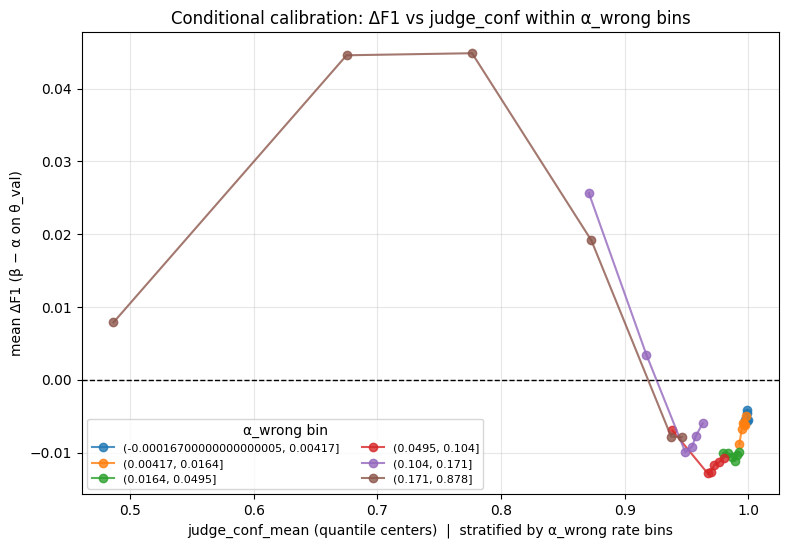

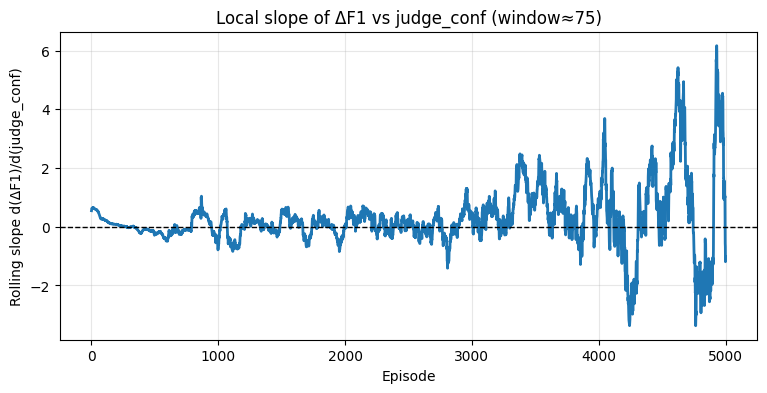

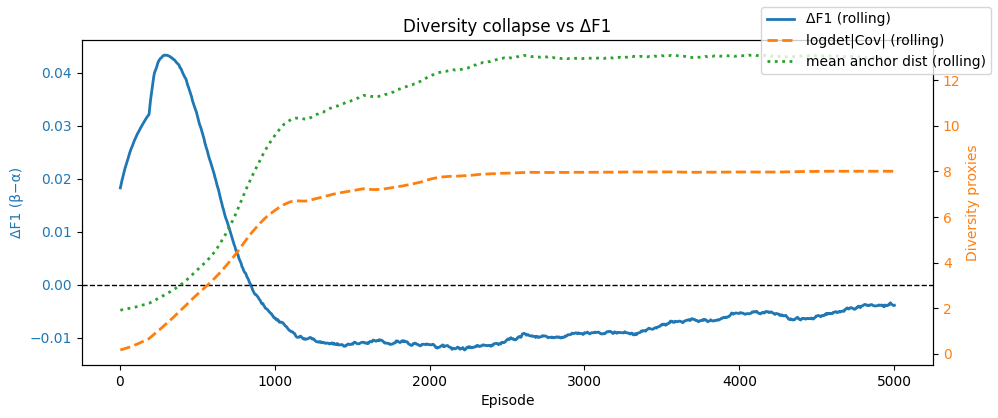

In [18]:
# === CONFIG (point to the experiment you're inspecting) ===
EXP_ROOT = "training_runs/EP5000_TRJ2000_REAL3000_BIAS0.35_NR1_TAU0.1_951360ce"  # change if needed
ROLL = 75          # rolling window for slopes/corrs
NBINS = 6          # bins for judge_conf and alpha_wrong conditioning

import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

def _seed_dirs(exp_root):
    exp_root = os.path.abspath(exp_root)
    seeds = []
    for d in sorted(os.listdir(exp_root)):
        p = os.path.join(exp_root, d)
        if d.startswith("seed_") and os.path.isfile(os.path.join(p, "metrics.csv")):
            seeds.append(p)
    if not seeds and os.path.isfile(os.path.join(exp_root, "metrics.csv")):
        seeds = [exp_root]
    if not seeds:
        raise SystemExit(f"No metrics found under {exp_root}")
    return seeds

def _read_metrics(sd):
    df = pd.read_csv(os.path.join(sd, "metrics.csv"))
    if "episode" not in df.columns:
        df.insert(0, "episode", np.arange(1, len(df) + 1))
    for c in df.columns:
        if c != "episode":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["__seed__"] = os.path.basename(sd)
    return df

def _mean_per_ep(df, cols):
    return df.groupby("episode")[cols].mean(numeric_only=True)

seed_dirs = _seed_dirs(EXP_ROOT)
dfs = [ _read_metrics(sd) for sd in seed_dirs ]
big = pd.concat(dfs, ignore_index=True).sort_values(["episode","__seed__"])
need = ["episode", "newr.judge_conf_mean", "align.delta_f1_val", "newr.alpha_wrong_rate"]
miss = [c for c in need if c not in big.columns]
if miss:
    raise SystemExit(f"Missing required columns in metrics.csv: {miss}")

# -------------- (1) CONDITIONAL CALIBRATION: ΔF1 vs judge_conf within alpha_wrong bins
agg = _mean_per_ep(big, ["newr.judge_conf_mean","align.delta_f1_val","newr.alpha_wrong_rate"]).dropna()
# Bin episodes by alpha_wrong_rate
alpha_bins = pd.qcut(agg["newr.alpha_wrong_rate"], q=NBINS, duplicates="drop")
groups = agg.groupby(alpha_bins, observed=True)

plt.figure(figsize=(9, 6))
for name, g in groups:
    if len(g) < 10: 
        continue
    # bin judge_conf inside this alpha bin into quantiles and compute mean ΔF1 per bin
    jc = g["newr.judge_conf_mean"]
    df1 = g["align.delta_f1_val"]
    jc_bins = pd.qcut(jc, q=min(NBINS, max(3, int(len(g)/30))), duplicates="drop")
    by = df1.groupby(jc_bins)
    centers = np.array([iv.mid for iv in by.mean().index])
    means = by.mean().values
    plt.plot(centers, means, marker="o", alpha=0.8, label=str(name))
plt.axhline(0, ls="--", lw=1, c="k")
plt.xlabel("judge_conf_mean (quantile centers)  |  stratified by α_wrong rate bins")
plt.ylabel("mean ΔF1 (β − α on θ_val)")
plt.title("Conditional calibration: ΔF1 vs judge_conf within α_wrong bins")
plt.legend(title="α_wrong bin", fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.show()

# -------------- (2) ROLLING LOCAL REGRESSION: slope of ΔF1 ~ judge_conf
# average across seeds per episode
ts = _mean_per_ep(big, ["newr.judge_conf_mean","align.delta_f1_val"]).dropna()
x = ts["newr.judge_conf_mean"].values
y = ts["align.delta_f1_val"].values
episodes = ts.index.values

def rolling_slope(x, y, w):
    n = len(x)
    out = np.full(n, np.nan)
    for i in range(n):
        L = max(0, i - w//2); R = min(n, i + w//2 + 1)
        xx, yy = x[L:R], y[L:R]
        if len(xx) < 5 or np.allclose(xx.std(), 0):
            continue
        X = np.c_[np.ones(len(xx)), xx]     # [1, x]
        beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
        out[i] = beta[1]  # slope wrt judge_conf
    return out

slope = rolling_slope(x, y, ROLL)
plt.figure(figsize=(9, 4))
plt.plot(episodes, slope, lw=2)
plt.axhline(0, ls="--", lw=1, c="k")
plt.xlabel("Episode")
plt.ylabel("Rolling slope d(ΔF1)/d(judge_conf)")
plt.title(f"Local slope of ΔF1 vs judge_conf (window≈{ROLL})")
plt.grid(alpha=0.3)
plt.show()

# -------------- (3) DIVERSITY COLLAPSE: spread of synthetic snapshots (if present)
# We’ll scan seed_*/synthetic_snapshots/*.npz and compute logdet|Cov| and mean pairwise distance.
def snapshot_stats(seed_dir):
    snap_dir = os.path.join(seed_dir, "synthetic_snapshots")
    snaps = sorted(glob.glob(os.path.join(snap_dir, "synthetic_ep*.npz")))
    rows = []
    for p in snaps:
        ep = int(os.path.splitext(os.path.basename(p))[0].split("ep")[1])
        try:
            d = np.load(p)
            X = np.asarray(d["x"])
            if X.ndim != 2 or len(X) < 5: 
                continue
            cov = np.cov(X.T)
            # numerical guard: add tiny ridge if nearly singular
            cov = cov + 1e-8*np.eye(cov.shape[0])
            logdet = np.log(np.linalg.det(cov))
            # mean pairwise distance (sampled if huge)
            if len(X) > 2000:
                idx = np.random.RandomState(0).choice(len(X), size=2000, replace=False)
                Xs = X[idx]
            else:
                Xs = X
            # simple average distance to 32 random anchors
            rs = np.random.RandomState(1).choice(len(Xs), size=min(32, len(Xs)), replace=False)
            anchors = Xs[rs]
            dists = np.sqrt(((Xs[None,:,:]-anchors[:,None,:])**2).sum(-1)).mean()
            rows.append((ep, logdet, dists))
        except Exception:
            pass
    if not rows: 
        return None
    out = pd.DataFrame(rows, columns=["episode","logdet_cov","mean_anchor_dist"]).sort_values("episode")
    return out

divs = []
for sd in seed_dirs:
    s = snapshot_stats(sd)
    if s is not None:
        s["__seed__"] = os.path.basename(sd)
        divs.append(s)

if divs:
    div = pd.concat(divs, ignore_index=True)
    div_mean = div.groupby("episode")[["logdet_cov","mean_anchor_dist"]].mean()
    # align with ΔF1 time series
    merged = div_mean.join(ts["align.delta_f1_val"], how="inner")
    fig, ax1 = plt.subplots(figsize=(10,4.2))
    ax1.plot(merged.index, merged["align.delta_f1_val"].rolling(ROLL,1,center=True).mean(), lw=2, label="ΔF1 (rolling)")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("ΔF1 (β−α)", color="C0"); ax1.tick_params(axis='y', labelcolor="C0")
    ax2 = ax1.twinx()
    ax2.plot(merged.index, merged["logdet_cov"].rolling(ROLL,1,center=True).mean(), lw=2, ls="--", label="logdet|Cov| (rolling)", color="C1")
    ax2.plot(merged.index, merged["mean_anchor_dist"].rolling(ROLL,1,center=True).mean(), lw=2, ls=":", label="mean anchor dist (rolling)", color="C2")
    ax2.set_ylabel("Diversity proxies", color="C1"); ax2.tick_params(axis='y', labelcolor="C1")
    ax1.axhline(0, ls="--", lw=1, c="k")
    fig.legend(loc="upper right")
    ax1.set_title("Diversity collapse vs ΔF1")
    fig.tight_layout()
    plt.show()
else:
    print("[info] No synthetic snapshots found; diversity panel skipped.")
